**Taller 3 - Solución de un problema de clasificación**


## 1. Importar librerias necesarias para el modelo

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler, RobustScaler

import os
from google.colab import drive

## 2. Carga de datos

In [5]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Revisión preliminar de datos

In [6]:
data = pd.read_csv('./breast-cancer1.csv', sep=',')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
#Cantidad y dimensionalidad de los datos
data.shape

(569, 32)

In [8]:
#Perfilamiento de los datos
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Eliminamos la columna 'id' por considerar que la misma no aporta valor al modelo:

In [9]:
data = data.drop(columns=['id'])

In [10]:
#Revisión de datos faltantes
print(f'Datos nulos: \n {data.isna().sum()}')

Datos nulos: 
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


No existen datos faltantes o nulos.

In [11]:
#Identificación de datos repetidos
print(f'Datos duplicados: {data.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

##3. Preparación de los sets de entrenamiento

In [12]:
# División de los datos (X) y variable objetivo (y)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis'].map({'M': 1, 'B': 0}).astype(np.float32) #Convertimos a númerica la variable objetivo para que pueda ser interpretada por nuestros modelos

X = X.apply(pd.to_numeric, errors='coerce')  # fuerza todo a numérico
X = X.astype(np.float32)

In [13]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [14]:
#Revisión preliminar de la variable objetivo
y.head()

,diagnosis
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


## 4. Creacion del modelo RMSprop
### Arquitectura 1:(5,5,5)
Red con tres capas ocultas, con 5 neuronas en cada capa, que implementa el optimizador RMSprop y tiene un máximo de 200 épocas.

In [15]:
#Creación y definición de la red neuronal
modelRMSprop = keras.Sequential()
#La primera capa necesita especificar la cantidad de columnas de datos que para nuestro caso es 30
modelRMSprop.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid',input_shape=(30,)))
modelRMSprop.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid'))
modelRMSprop.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid'))
#La última capa de salida, por ser clasificación binaria, solo tiene una salida
modelRMSprop.add(layers.Dense(1, kernel_initializer='uniform', activation = 'sigmoid'))
#Definición del optimizador
optRMSprop = keras.optimizers.RMSprop()
#Compila el modelo con una función de costo, y unas metricas para evaluar el modelo posteriormente
modelRMSprop.compile(loss='binary_crossentropy', optimizer=optRMSprop, metrics = [tf.keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
historyRMSprop = modelRMSprop.fit(X_train, y_train, epochs = 200)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.6294 - loss: 0.6863   
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6351 - loss: 0.6800 
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6216 - loss: 0.6777 
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6107 - loss: 0.6765 
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6346 - loss: 0.6685 
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6420 - loss: 0.6643 
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.6100 - loss: 0.6715  
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6255 - loss: 0.6653 
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.6218 - loss: 0.6654  
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.6145 - loss: 0.6672 
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accu

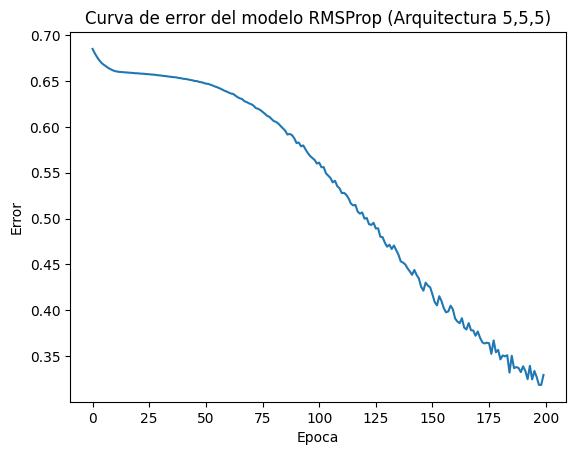

In [17]:
plt.plot(historyRMSprop.history['loss'])
plt.title('Curva de error del modelo RMSProp (Arquitectura 5,5,5)')
plt.ylabel('Error')
plt.xlabel('Epoca')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9372 - loss: 0.2870  
Test loss: 0.30512356758117676
Test accuracy: 0.9210526347160339
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


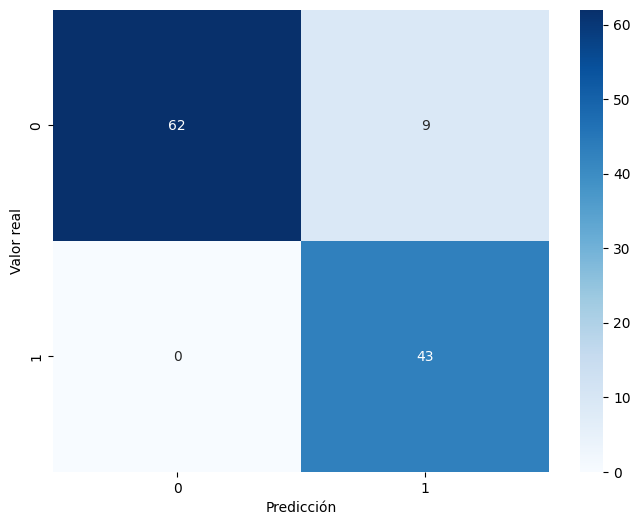

In [18]:
#Evaluación del modelo:
lossRMSprop, accuracyRMSprop = modelRMSprop.evaluate(X_test, y_test)
print('Test loss:', lossRMSprop)
print('Test accuracy:', accuracyRMSprop)

#Predicción en formato de probabilidad:
y_pred_RMSprop = modelRMSprop.predict(X_test)

#Predicción en formato 1 y 0
y_pred = (y_pred_RMSprop > 0.5).astype("int32")

#Generación de matriz de confusión
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap='Blues', annot=True, fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### Arquitectura 2:(8)
Red con una capa oculta, con 8 neuronas, que implementa el optimizador RMSprop y tiene un máximo de 200 épocas.

In [19]:
#Creación y definición de la red neuronal
modelRMSprop2 = keras.Sequential()
#La primera capa necesita especificar la cantidad de columnas de datos
modelRMSprop2.add(layers.Dense(8, kernel_initializer='uniform', activation = 'sigmoid',input_shape=(30,)))

#La última capa de salida, por ser clasificación binaria, solo tiene una salida
modelRMSprop2.add(layers.Dense(1, kernel_initializer='uniform', activation = 'sigmoid'))
#Definición del optimizador
optRMSprop2 = keras.optimizers.RMSprop()
#Compila el modelo con una función de costo, y unas metricas para evaluar el modelo posteriormente
modelRMSprop2.compile(loss='binary_crossentropy', optimizer=optRMSprop2, metrics = [tf.keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
historyRMSprop2 = modelRMSprop2.fit(X_train, y_train, epochs = 200)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7008 - loss: 0.6762  
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7943 - loss: 0.6555 
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8259 - loss: 0.6463 
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8336 - loss: 0.6262 
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8763 - loss: 0.6182 
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8666 - loss: 0.6083  
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8434 - loss: 0.6035  
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8640 - loss: 0.5791 
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8775 - loss: 0.5852  
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8408 - loss: 0.5781 
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accu

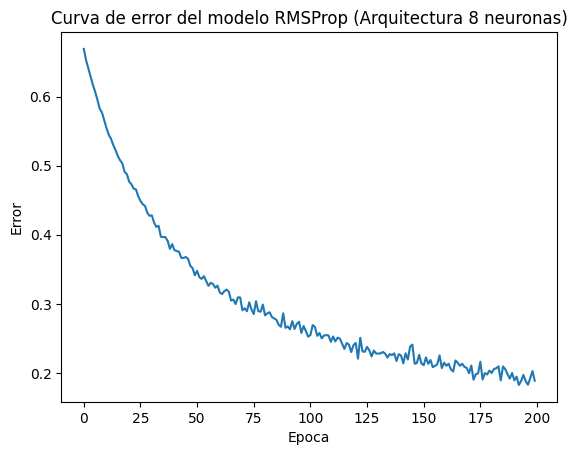

In [21]:
plt.plot(historyRMSprop2.history['loss'])
plt.title('Curva de error del modelo RMSProp (Arquitectura 8 neuronas)')
plt.ylabel('Error')
plt.xlabel('Epoca')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9606 - loss: 0.1419 
Test loss: 0.15454111993312836
Test accuracy: 0.9561403393745422
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


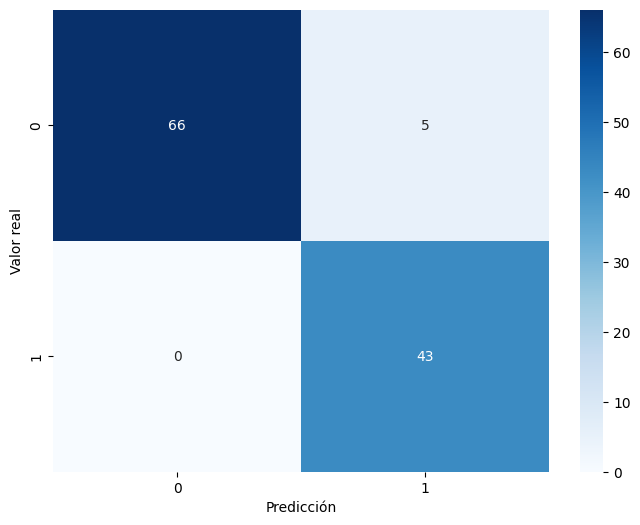

In [22]:
#Evaluación del modelo:
lossRMSprop2, accuracyRMSprop2 = modelRMSprop2.evaluate(X_test, y_test)
print('Test loss:', lossRMSprop2)
print('Test accuracy:', accuracyRMSprop2)

#Predicción en formato de probabilidad:
y_pred_RMSprop2 = modelRMSprop2.predict(X_test)

#Predicción en formato 1 y 0
y_pred2 = (y_pred_RMSprop2 > 0.5).astype("int32")

#Generar matriz de confusión
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred2), cmap='Blues', annot=True, fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

##5. Creacion del modelo con Adam
### Arquitectura 3: (5,5,5)
Red con 3 capas ocultas, con 5 neuronas en cada capa, que implementa el optimizador Adam y tiene un máximo de 200 épocas.

In [23]:
#Creación y definición de la red neuronal
modelAdam = keras.Sequential()
#La primera capa necesita especificar la cantidad de columnas de datos
modelAdam.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid',input_shape=(30,)))
modelAdam.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid'))
modelAdam.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid'))
#La última capa de salida, por ser clasificación binaria, solo tiene una salida
modelAdam.add(layers.Dense(1, kernel_initializer='uniform', activation = 'sigmoid'))
#Definición del optimizador
optAdam = keras.optimizers.Adam()
#Compila el modelo con una función de costo, y unas metricas para evaluar el modelo posteriormente
modelAdam.compile(loss='binary_crossentropy', optimizer=optAdam, metrics = [tf.keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
historyAdam = modelAdam.fit(X_train, y_train, epochs = 200)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.6218 - loss: 0.6905
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6311 - loss: 0.6851 
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6508 - loss: 0.6783 
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6374 - loss: 0.6747 
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6313 - loss: 0.6717 
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6626 - loss: 0.6613 
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6472 - loss: 0.6619 
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6637 - loss: 0.6546 
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6058 - loss: 0.6712 
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.5976 - loss: 0.6736 
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy:

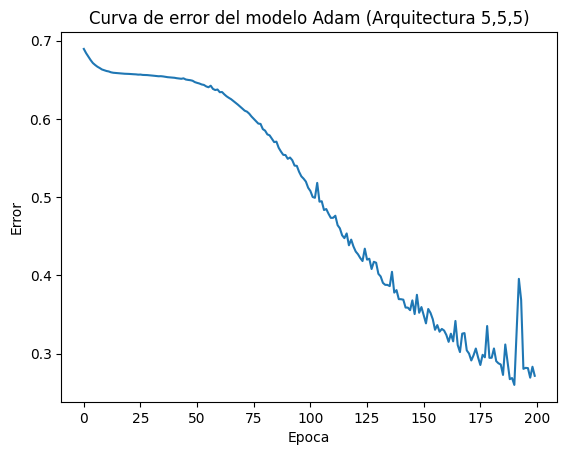

In [25]:
plt.plot(historyAdam.history['loss'])
plt.title('Curva de error del modelo Adam (Arquitectura 5,5,5)')
plt.ylabel('Error')
plt.xlabel('Epoca')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.9651 - loss: 0.1953  


Test loss: 0.20243339240550995
Test accuracy: 0.9649122953414917
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.9651 - loss: 0.1953 
Test loss: 0.20243339240550995
Test accuracy: 0.9649122953414917


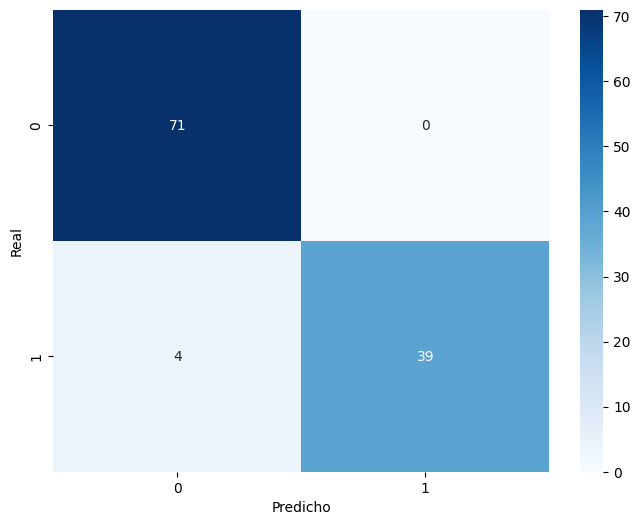

In [26]:
lossAdam, accuracyAdam = modelAdam.evaluate(X_test, y_test)
print('Test loss:', lossAdam)
print('Test accuracy:', accuracyAdam)

# Predicciones (devuelve probabilidades entre 0 y 1)
y_pred_proba = modelAdam.predict(X_test)

#Convertir probabilidades a clases 0 y 1
y_pred_Adam = (y_pred_proba > 0.5).astype("int32")

#Evaluación:
lossAdam, accuracyAdam = modelAdam.evaluate(X_test, y_test)
print('Test loss:', lossAdam)
print('Test accuracy:', accuracyAdam)

#Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_Adam), cmap='Blues', annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

### Arquitectura 4: (8)
Red con 1 capa oculta, con 8 neuronas, que implementa el optimizador Adam y tiene un máximo de 200 épocas.

In [27]:
#Creación y definición de la red neuronal
modelAdam2 = keras.Sequential()
#La primera capa necesita especificar la cantidad de columnas de datos
modelAdam2.add(layers.Dense(5, kernel_initializer='uniform', activation = 'sigmoid',input_shape=(30,)))
#La última capa de salida, por ser clasificación binaria, solo tiene una salida
modelAdam2.add(layers.Dense(1, kernel_initializer='uniform', activation = 'sigmoid'))
#Definición del optimizador
optAdam2 = keras.optimizers.Adam()
#Compila el modelo con una función de costo, y unas metricas para evaluar el modelo posteriormente
modelAdam2.compile(loss='binary_crossentropy', optimizer=optAdam2, metrics = [tf.keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
historyAdam2 = modelAdam2.fit(X_train, y_train, epochs = 200)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.3947 - loss: 0.6978
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.6684 - loss: 0.6752  
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7948 - loss: 0.6652  
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.7528 - loss: 0.6542 
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8251 - loss: 0.6375 
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8600 - loss: 0.6260 
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8325 - loss: 0.6212 
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8420 - loss: 0.6094 
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8939 - loss: 0.5889 
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8662 - loss: 0.5836 
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accurac

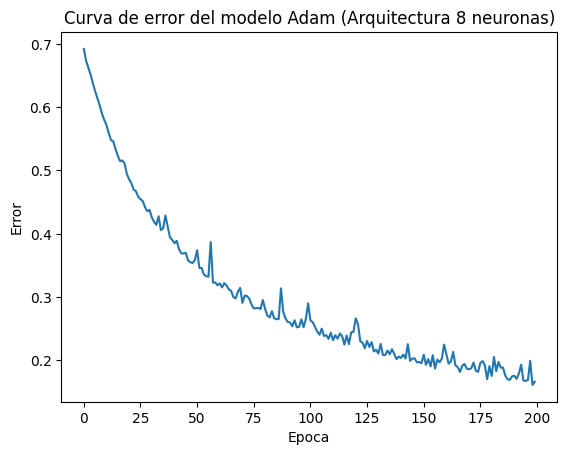

In [29]:
plt.plot(historyAdam2.history['loss'])
plt.title('Curva de error del modelo Adam (Arquitectura 8 neuronas)')
plt.ylabel('Error')
plt.xlabel('Epoca')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.9560 - loss: 0.1179  
Test loss: 0.12148609757423401
Test accuracy: 0.9473684430122375
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9560 - loss: 0.1179 
Test loss: 0.12148609757423401
Test accuracy: 0.9473684430122375


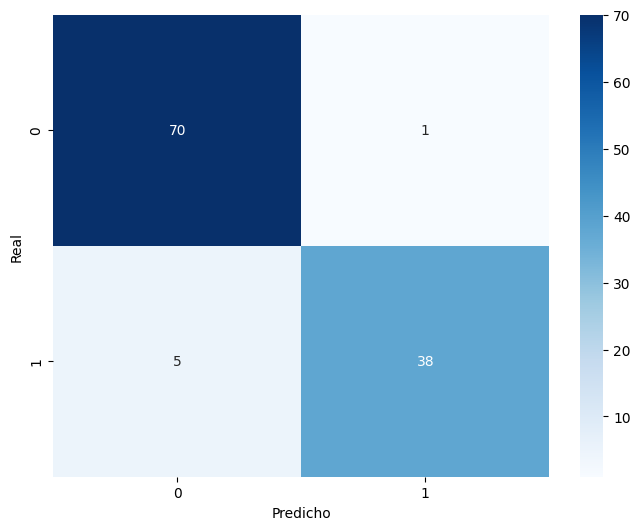

In [30]:
lossAdam2, accuracyAdam2 = modelAdam2.evaluate(X_test, y_test)
print('Test loss:', lossAdam2)
print('Test accuracy:', accuracyAdam2)

# Predicciones (devuelve probabilidades entre 0 y 1)
y_pred_proba2 = modelAdam2.predict(X_test)

#Convertir probabilidades a clases 0 y 1
y_pred_Adam2 = (y_pred_proba2 > 0.5).astype("int32")

#Evaluación:
lossAdam2, accuracyAdam2 = modelAdam2.evaluate(X_test, y_test)
print('Test loss:', lossAdam2)
print('Test accuracy:', accuracyAdam2)

#Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_Adam2), cmap='Blues', annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

##6. Conclusiones

Comparación del desempeño entre arquitecturas y optimizadores.

¿A que cree que se deben los resultados obtenidos?

**Respuesta:**


Tabla comparativa de resultados:

In [31]:
#Se genera una tabla comparativa con los resultados de los modelos evaluados
tabla = pd.DataFrame(
    {
        "RMSProp (5,5,5)": [lossRMSprop, accuracyRMSprop],
        "RMSProp (8)": [lossRMSprop2, accuracyRMSprop2],
        "Adam (5,5,5)": [lossAdam, accuracyAdam],
        "Adam (8)": [lossAdam2, accuracyAdam2],
    },
    index=["Test Loss", "Test Accuracy"]
)

print(tabla)

               RMSProp (5,5,5)  RMSProp (8)  Adam (5,5,5)  Adam (8)
Test Loss             0.305124     0.154541      0.202433  0.121486
Test Accuracy         0.921053     0.956140      0.964912  0.947368


*   Los resultados muestran que el desempeño del modelo Adam supera al del modelo RMSprop. Esto debido a la naturaleza mismo del optimizador, ya que no solo cuenta con el manejo del momentum sino que adicionalmente adapta sus tasas de aprendizaje (corrección de sesgo), haciendolo más estable y más eficiente.
*   A menor profundidad y mayor neuronas se obtiene un mejor desempeño. Podemos observar que para este set de datos no tan complejo, mayor número de capas puede introducir mayor ruido, dificultando de esta manera la generalización; por lo tanto una sola capa con mas neuronas ofrece suficiente capacidad de representación, evitando la pérdida de señal de capas intermedias. Esto se puede ver para ambos modelos (RMSprop y Adam). Esto mismo se puede observar al comparar las imagenes de error de la gráfica de la arquitectura de 1 capa de 8 neuronas con respecto a la arquitectura del mismo modelo pero con 3 capas y 5 neuronas; para el primer caso vemos que la gráfica del modelo menos profundo es más 'limpia' y más estable que la de su contraparte mas profunda, indicando menos indecisión en el momento de calcular el error.
*   Así mismo podemos llegar a la conclusión que debido a la naturaleza del set de datos al contar con 30 entradas se obtiene suficiente información descriptiva que nos permite ejecutar las labores de clasificación de una mejor manera para modelos menos profundos.
*   Analizando el resultado de 'Test Loss' podemos ver como la evolución de los cuatro modelos muestra una clara tendencia de mejora al simplificar la arquitectura y al usar Adam. Lo anterior confirma que Adam es mas confiable no solo por su precisión (accuracy) sino porque minimiza el error en el momento de hacer las predicciones.

